# Part 1 – Present an Overview of Hyper-Parameter Optimization: A Review of Algorithms and Applications (from the attached paper)


- Manual tuning is inefficient; automated hyperparameter optimization (HPO) is needed.
- Hyperparameters are divided into training-related (learning rate, optimizers, batch size, dropout, etc.) and architecture-related (number of layers, hidden units, activation functions).
- Hyperparameters affects accuracy, convergence speed, and resource usage
- Random Search is more effective than Grid Search. both are simple
- Bayesian Optimization is efficient
Challenges:
- Scalability: Deep models takes too much computational cost for grid/BO
- Training full models is expensive
- Parallelism is important to reduce runtime

# Part 2- Image Classification & Hyperparameter Turning on Fashion-MNIST.

The objective of this project is to predict fashion classes such as pants, shirts, and shoes from grayscale images. This guided project is practical and directly applicable to the fashion industry. You can add this project to your portfolio of projects which is essential for your next job interview.
Learning Objectives
________________________________________
•	Perform data cleaning, feature engineering and visualization
•	Understand the theory and intuition behind artificial neural networks
•	Build, train and test an artificial neural network model in Keras and Tensorflow
Overview of Health Care Systems and


__Objective:__ To classify images of different pieces of clothing.

__Client & Data-Set:__ Fashion-MNIST is a dataset of Zalando's article images—consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes. 

Data-set is publicly available on kaggle and __[Zalando Fashion MNIST repository](https://github.com/zalandoresearch/fashion-mnist)__ on Github.

Fashion-MNIST is intended as direct drop-in replacement for the original MNIST dataset. It shares the same image size and structure of training and testing splits.

__Business Impact:__ E-commerce companies have lots of items for sale online which requires lots of images to be displayed on their websites, applications and on social media. And it takes lot of human power and time to separate these images into respective groups. This classifier which we are going to build helps businesses to categorize images into respective groups.

__Labels:__ Each training and test example is assigned to one of the following labels:

•	0 - T-shirt/top 
•	1 - Trouser 
•	2 - Pullover 
•	3 - Dress 
•	4 - Coat 
•	5 - Sandal 
•	6 - Shirt 
•	7 - Sneaker 
•	8 - Bag 
•	9 - Ankle boot 

# TASK #1: UNDERSTAND THE PROBLEM STATEMENT  

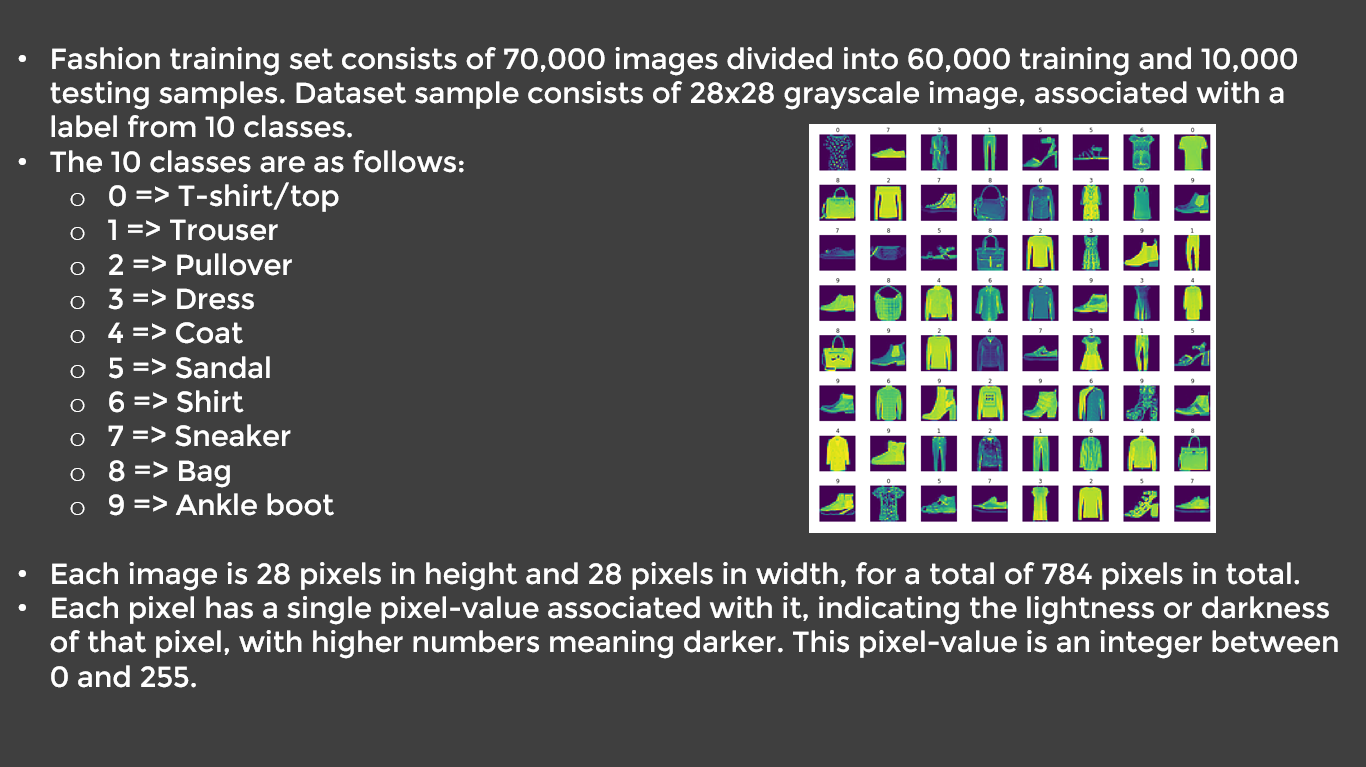

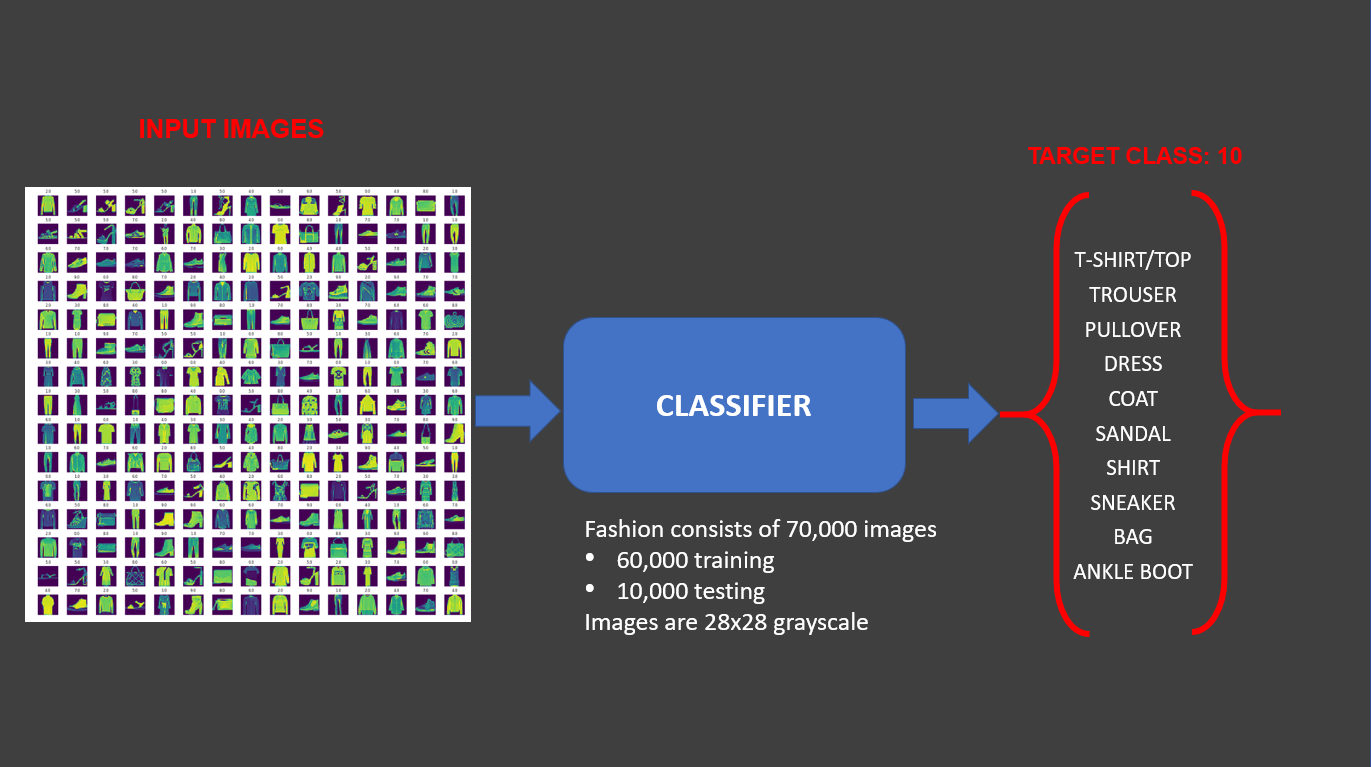

In [1]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
import keras
from keras.models import Sequential
from tensorflow.keras.utils import to_categorical  # tensorflow.

# from keras.utils.vis_utils import plot_model
from tensorflow.keras.utils import plot_model
from tensorflow.keras.optimizers import Adam  # tensorflow.
from keras.layers import (
    Dense,
    Activation,
    Dropout,
    Flatten,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    ZeroPadding2D,
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import EarlyStopping

# TASK #2: IMPORT LIBRARIES AND DATASETS

In [2]:
import tensorflow as tf
fashion_mnist = tf.keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [3]:
import matplotlib.pyplot as plt
from jupyterthemes import jtplot

jtplot.style(theme="monokai", context="notebook", ticks=True, grid=False)
# setting the style of the notebook to be monokai theme
# this line of code is important to ensure that we are able to see the x and y axes clearly
# If you don't run this code line, you will notice that the xlabel and ylabel on any plot is black on black and it will be hard to see them.

**PRACTICE OPPORTUNITY #1:**
- **Check out the sizes of both training and testing datasets**

In [4]:
# Check the sizes of training and testing datasets
print("Training dataset:")
print(f"Training images shape: {train_images.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Number of training samples: {train_images.shape[0]}")

print("\nTesting dataset:")
print(f"Test images shape: {test_images.shape}")  
print(f"Test labels shape: {test_labels.shape}")
print(f"Number of test samples: {test_images.shape[0]}")

print(f"\nTotal samples: {train_images.shape[0] + test_images.shape[0]}")

Training dataset:
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Number of training samples: 60000

Testing dataset:
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)
Number of test samples: 10000

Total samples: 70000


# TASK #3: PERFORM DATA VISUALIZATION

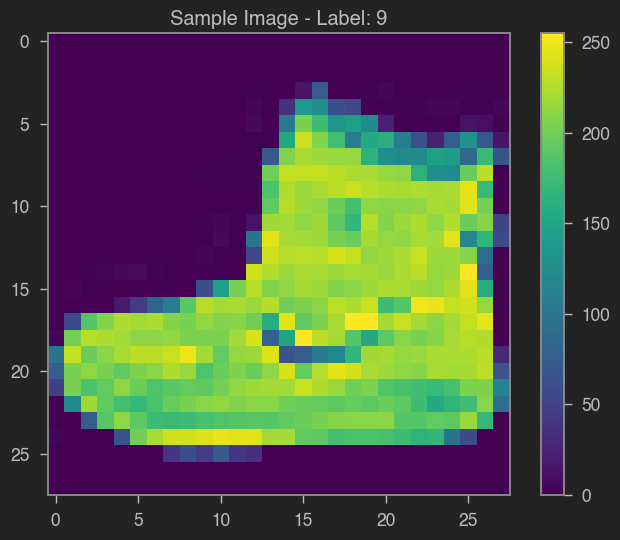

Image shape: (28, 28)
Label: 9
Pixel value range: 0 to 255


In [5]:
# Select a sample image and visualize it
plt.figure(figsize=(8, 6))
plt.imshow(train_images[0])
plt.title(f"Sample Image - Label: {train_labels[0]}")
plt.colorbar()
plt.show()

print(f"Image shape: {train_images[0].shape}")
print(f"Label: {train_labels[0]}")
print(f"Pixel value range: {train_images[0].min()} to {train_images[0].max()}")

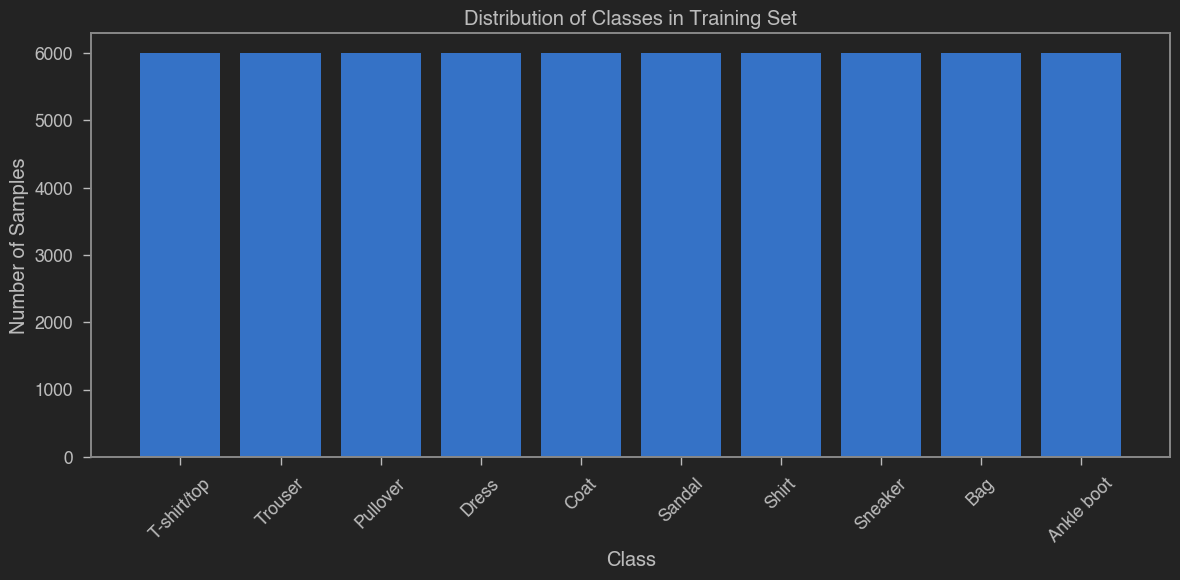

Class 0: T-shirt/top - 6000 samples
Class 1: Trouser - 6000 samples
Class 2: Pullover - 6000 samples
Class 3: Dress - 6000 samples
Class 4: Coat - 6000 samples
Class 5: Sandal - 6000 samples
Class 6: Shirt - 6000 samples
Class 7: Sneaker - 6000 samples
Class 8: Bag - 6000 samples
Class 9: Ankle boot - 6000 samples


In [6]:
# Define class names for better understanding
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

# Show class distribution
unique, counts = np.unique(train_labels, return_counts=True)
plt.figure(figsize=(12, 6))
plt.bar(unique, counts)
plt.title("Distribution of Classes in Training Set")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(unique, class_names, rotation=45)
plt.tight_layout()
plt.show()

for i, class_name in enumerate(class_names):
    print(f"Class {i}: {class_name} - {counts[i]} samples")

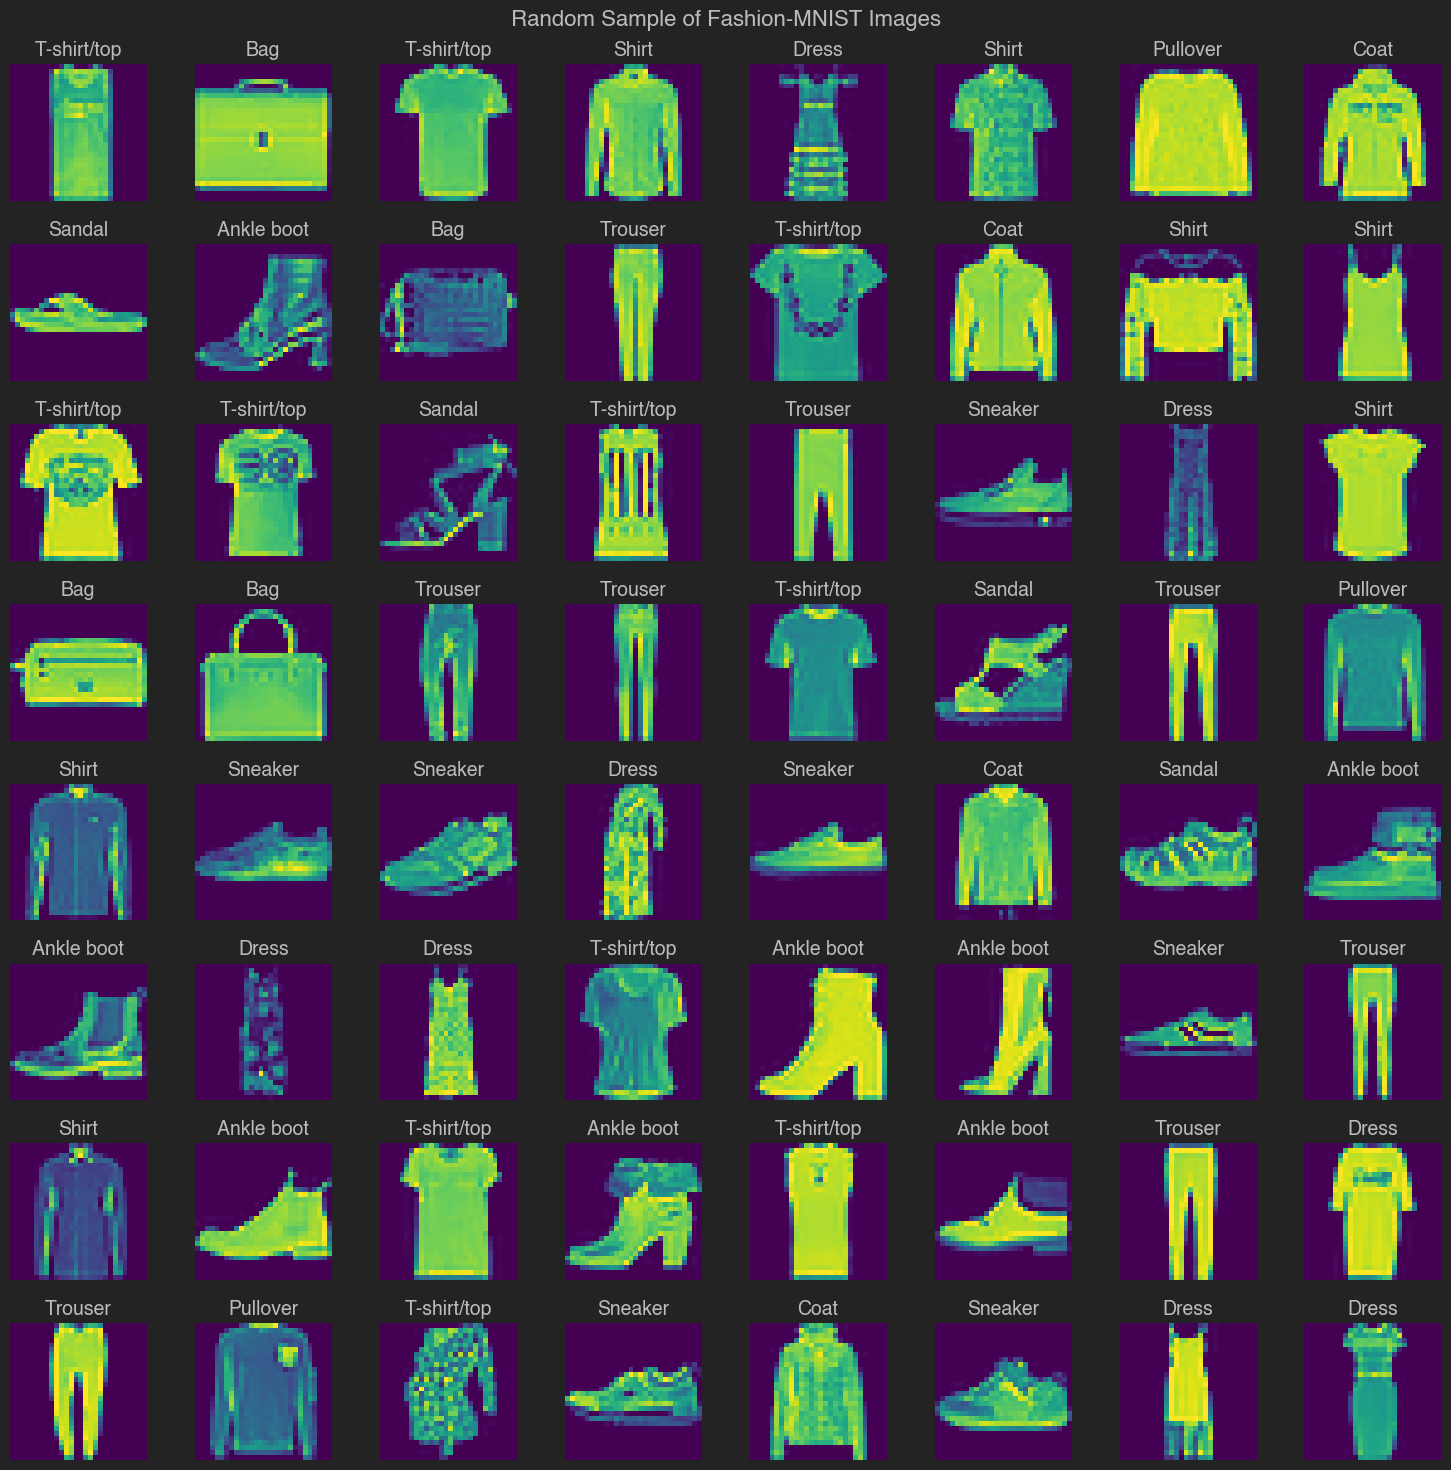

In [7]:
# Remember the 10 classes decoding is as follows:
# 0 => T-shirt/top
# 1 => Trouser
# 2 => Pullover
# 3 => Dress
# 4 => Coat
# 5 => Sandal
# 6 => Shirt
# 7 => Sneaker
# 8 => Bag
# 9 => Ankle boot

# Create a 8x8 grid of random images
W_grid = 8
L_grid = 8

fig, axes = plt.subplots(L_grid, W_grid, figsize=(15, 15))
axes = axes.ravel()

# Select random indices
n_samples = L_grid * W_grid
random_indices = np.random.choice(len(train_images), n_samples, replace=False)

for i in range(n_samples):
    axes[i].imshow(train_images[random_indices[i]])
    axes[i].set_title(f"{class_names[train_labels[random_indices[i]]]}", fontsize=14)
    axes[i].axis("off")

plt.suptitle("Random Sample of Fashion-MNIST Images", fontsize=16)
plt.tight_layout()
plt.show()

**PRACTICE OPPORTUNITY #2:**
- **Plot a grid containing 144 images and perform a sanity check on the data** 

Creating a 12x12 grid with 144 images


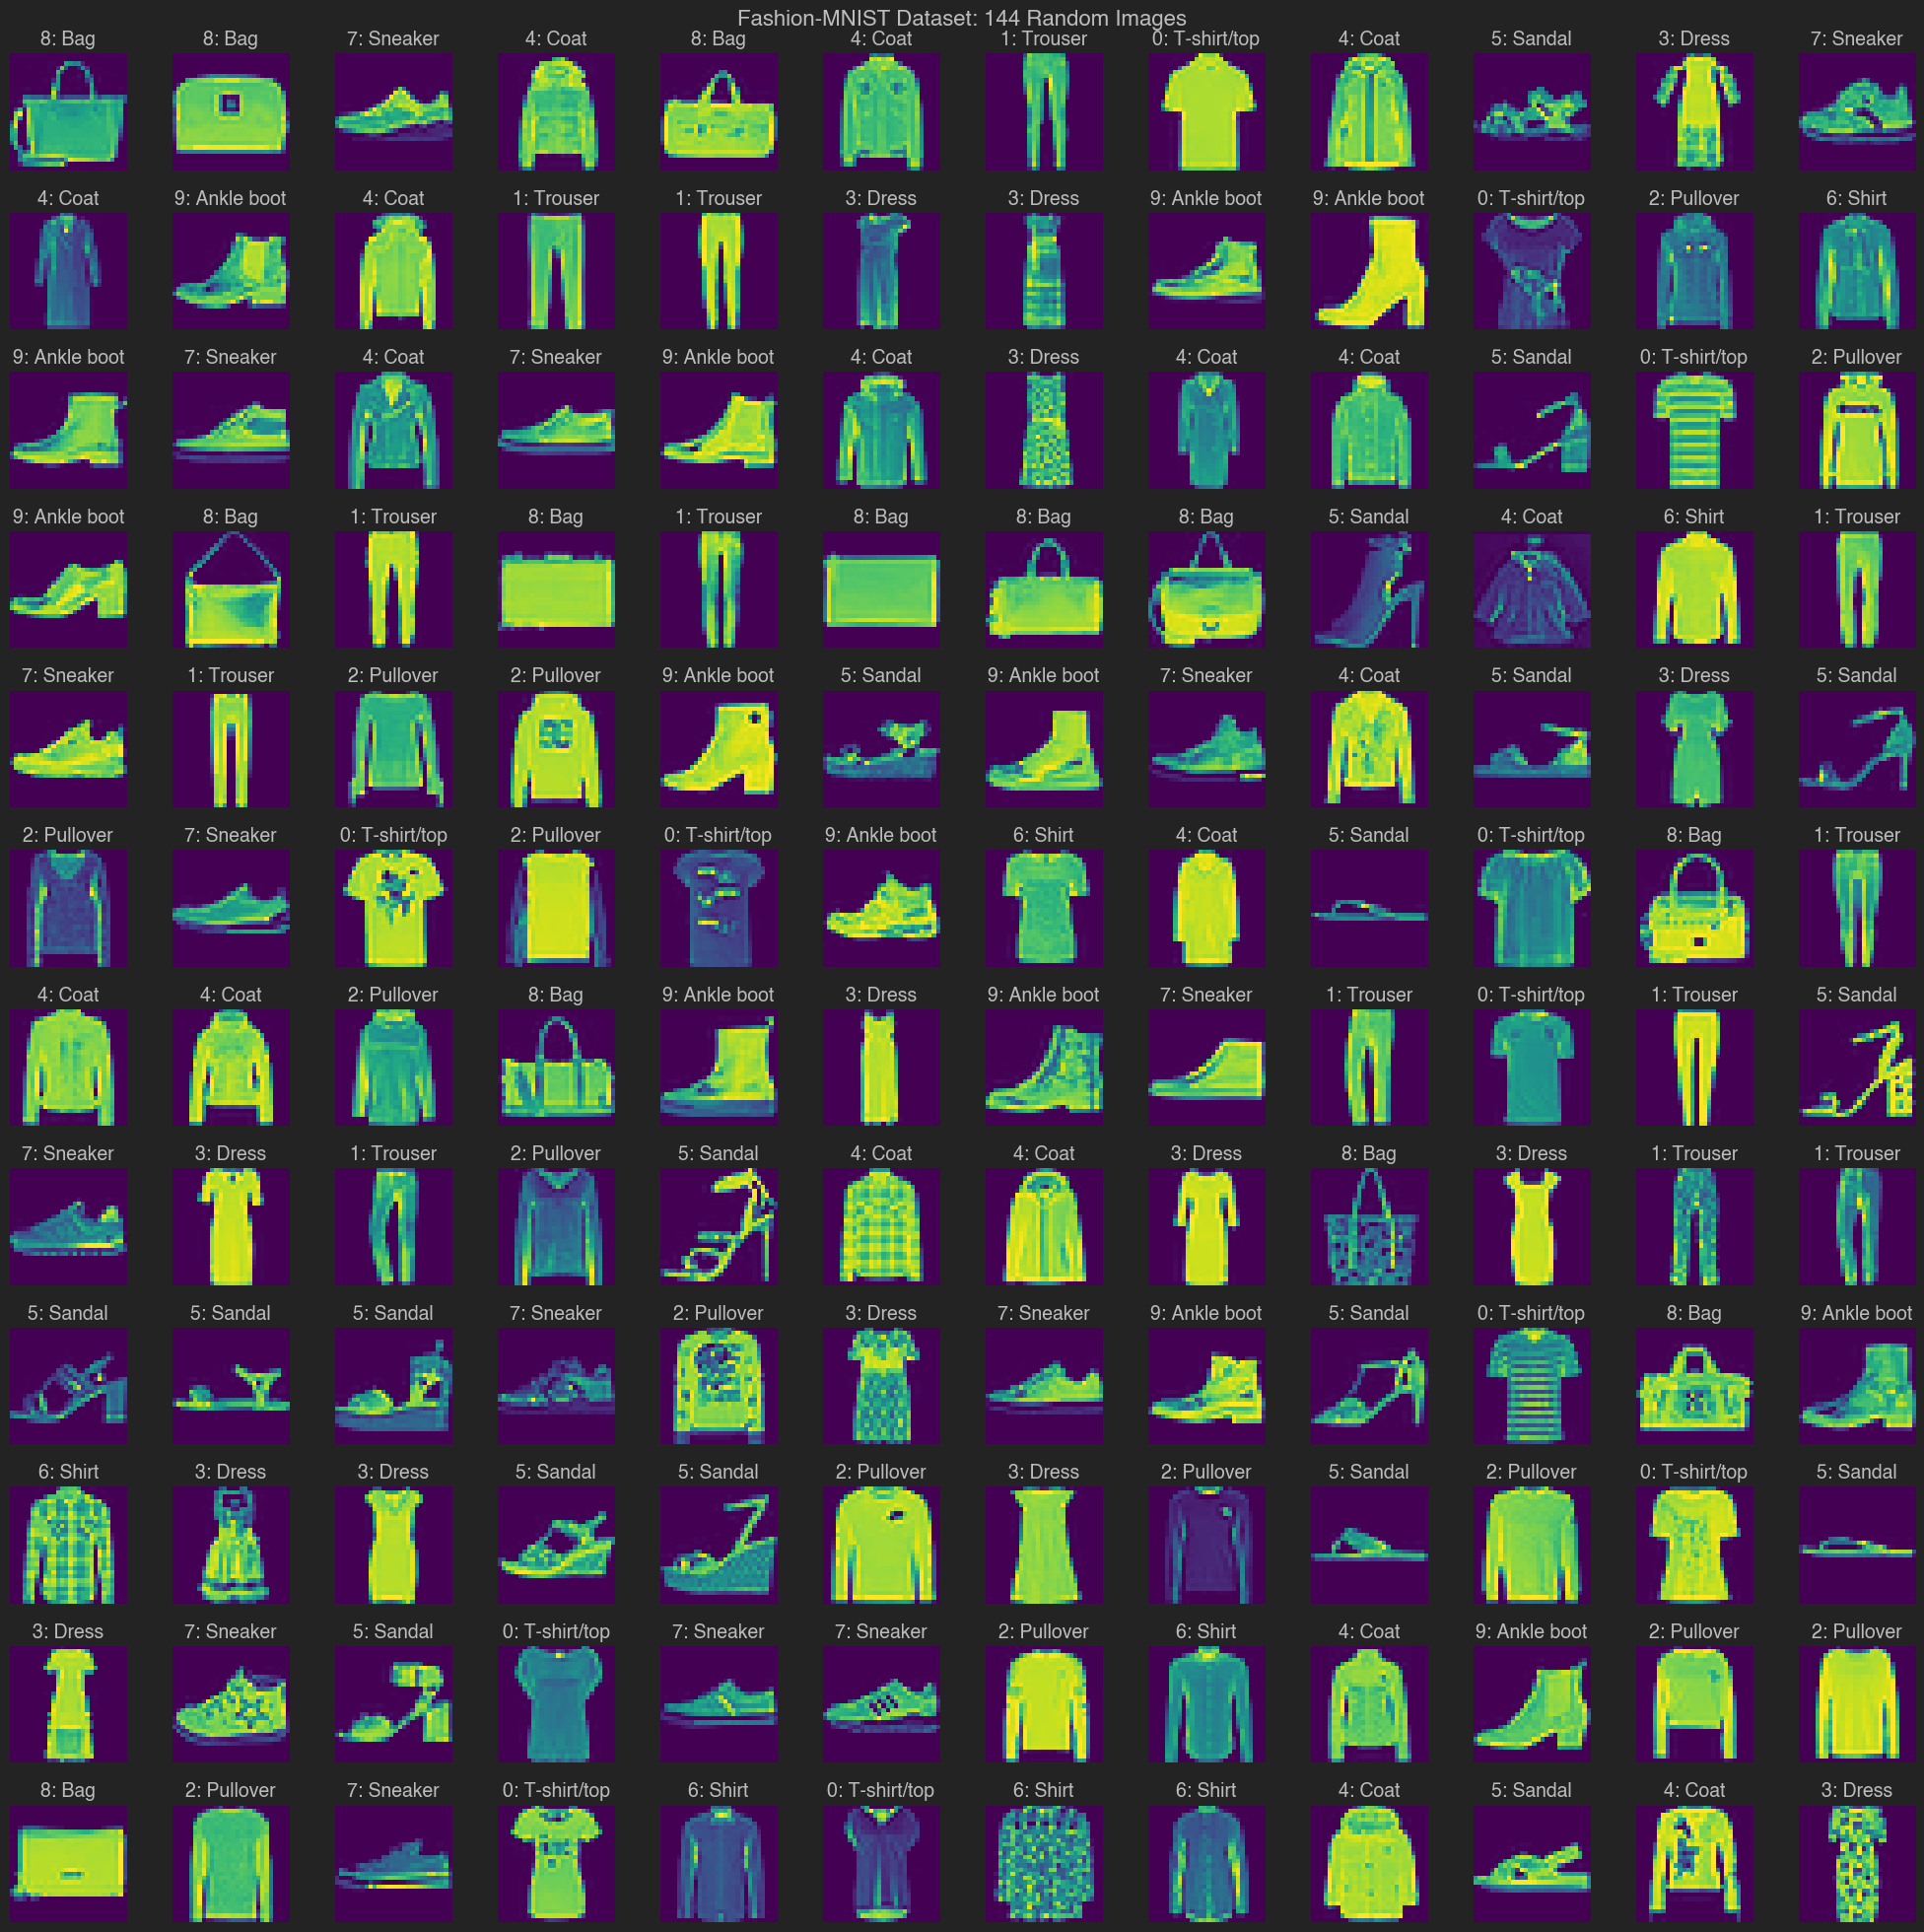


DATA SANITY CHECKS
1. DATA SHAPE VERIFICATION:
   Training images shape: (60000, 28, 28)
   Training labels shape: (60000,)
   Test images shape: (10000, 28, 28)
   Test labels shape: (10000,)

2. DATA TYPE VERIFICATION:
   Training images dtype: uint8
   Training labels dtype: uint8
   Test images dtype: uint8
   Test labels dtype: uint8

3. PIXEL VALUE RANGE VERIFICATION:
   Training images - Min: 0, Max: 255
   Test images - Min: 0, Max: 255

4. LABEL RANGE VERIFICATION:
   Training labels - Min: 0, Max: 9
   Test labels - Min: 0, Max: 9
   Unique labels in training: [np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9)]
   Unique labels in test: [np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9)]

5. CLASS DISTRIBUTION ANALYSIS:
   Training set class distribution:
     Class 0 (T-shirt/top): 6000 samples (10.0%)
     Class 1 (Tr

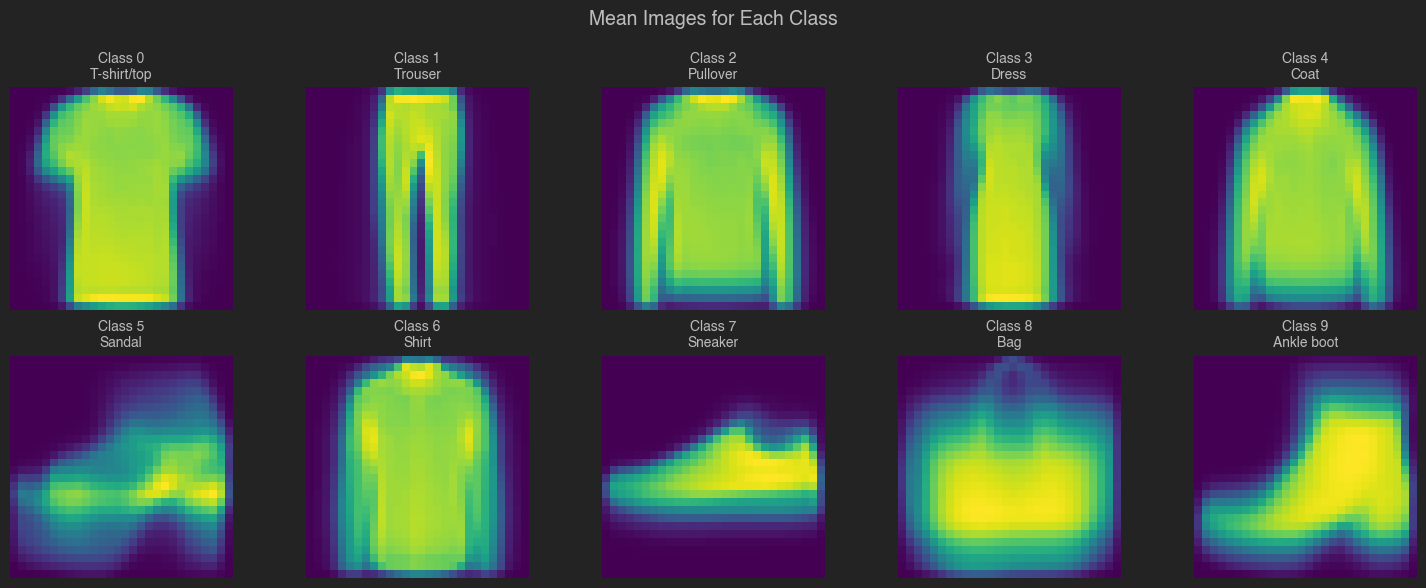

In [8]:
# Set up the grid dimensions for 144 images
W_grid = 12
L_grid = 12
total_images = W_grid * L_grid

print(f"Creating a {L_grid}x{W_grid} grid with {total_images} images")

# Create the figure and subplots
fig, axes = plt.subplots(L_grid, W_grid, figsize=(20, 20))
axes = axes.ravel()  # Flatten the 2D array of axes to 1D for easier indexing

# Select random indices for variety
np.random.seed(42)  # For reproducible results
random_indices = np.random.choice(len(train_images), total_images, replace=False)

# Define class names for reference
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

# Plot each image
for i in range(total_images):
    idx = random_indices[i]
    axes[i].imshow(train_images[idx])
    axes[i].set_title(
        f"{train_labels[idx]}: {class_names[train_labels[idx]]}", fontsize=14
    )
    axes[i].axis("off")

plt.suptitle("Fashion-MNIST Dataset: 144 Random Images", fontsize=16)
plt.tight_layout()
plt.show()

# SANITY CHECKS
print("\n" + "=" * 60)
print("DATA SANITY CHECKS")
print("=" * 60)

# Check 1: Verify data shapes
print("1. DATA SHAPE VERIFICATION:")
print(f"   Training images shape: {train_images.shape}")
print(f"   Training labels shape: {train_labels.shape}")
print(f"   Test images shape: {test_images.shape}")
print(f"   Test labels shape: {test_labels.shape}")

# Check 2: Verify data types
print("\n2. DATA TYPE VERIFICATION:")
print(f"   Training images dtype: {train_images.dtype}")
print(f"   Training labels dtype: {train_labels.dtype}")
print(f"   Test images dtype: {test_images.dtype}")
print(f"   Test labels dtype: {test_labels.dtype}")

# Check 3: Verify pixel value ranges
print("\n3. PIXEL VALUE RANGE VERIFICATION:")
print(f"   Training images - Min: {train_images.min()}, Max: {train_images.max()}")
print(f"   Test images - Min: {test_images.min()}, Max: {test_images.max()}")

# Check 4: Verify label ranges
print("\n4. LABEL RANGE VERIFICATION:")
print(f"   Training labels - Min: {train_labels.min()}, Max: {train_labels.max()}")
print(f"   Test labels - Min: {test_labels.min()}, Max: {test_labels.max()}")
print(f"   Unique labels in training: {sorted(np.unique(train_labels))}")
print(f"   Unique labels in test: {sorted(np.unique(test_labels))}")

# Check 5: Class distribution
print("\n5. CLASS DISTRIBUTION ANALYSIS:")
train_unique, train_counts = np.unique(train_labels, return_counts=True)
test_unique, test_counts = np.unique(test_labels, return_counts=True)

print("   Training set class distribution:")
for i, (label, count) in enumerate(zip(train_unique, train_counts)):
    print(
        f"     Class {label} ({class_names[label]}): {count} samples ({count/len(train_labels)*100:.1f}%)"
    )

print("\n   Test set class distribution:")
for i, (label, count) in enumerate(zip(test_unique, test_counts)):
    print(
        f"     Class {label} ({class_names[label]}): {count} samples ({count/len(test_labels)*100:.1f}%)"
    )


# Check 6: Sample some specific images for manual verification
print("\n6. SAMPLE IMAGE VERIFICATION:")
for class_idx in [0, 1, 2]:  # Check first 3 classes
    sample_indices = np.where(train_labels == class_idx)[0][:3]
    print(
        f"   Class {class_idx} ({class_names[class_idx]}) sample indices: {sample_indices}"
    )

print("\n" + "=" * 60)
print("SANITY CHECK COMPLETED!")
print("=" * 60)

# Additional visualization: Show mean image for each class
print("\n7. MEAN IMAGES PER CLASS:")
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for class_idx in range(10):
    class_images = train_images[train_labels == class_idx]
    mean_image = np.mean(class_images, axis=0)

    axes[class_idx].imshow(mean_image)
    axes[class_idx].set_title(
        f"Class {class_idx}\n{class_names[class_idx]}", fontsize=10
    )
    axes[class_idx].axis("off")

plt.suptitle("Mean Images for Each Class", fontsize=14)
plt.tight_layout()
plt.show()

# TASK #4: PREPARE THE DATA FOR TRAINING

In [9]:
# Step 1: Normalize the data (0-255 to 0-1)
X_train = train_images.astype("float32") / 255.0
X_test = test_images.astype("float32") / 255.0

print("Data normalized!")

# Step 2: Convert labels to categorical (one-hot encoding)
number_cat = 10
y_train = tf.keras.utils.to_categorical(train_labels, number_cat)
y_test = tf.keras.utils.to_categorical(test_labels, number_cat)

print("Labels converted to categorical!")

# Step 3: Reshape data for CNN (add channel dimension)
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

print("Data reshaped for CNN!")

# Check final shapes
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Data normalized!
Labels converted to categorical!
Data reshaped for CNN!
X_train shape: (60000, 28, 28, 1)
y_train shape: (60000, 10)
X_test shape: (10000, 28, 28, 1)
y_test shape: (10000, 10)


# TASK #5: BUILD A DEEP LEARNING MODEL

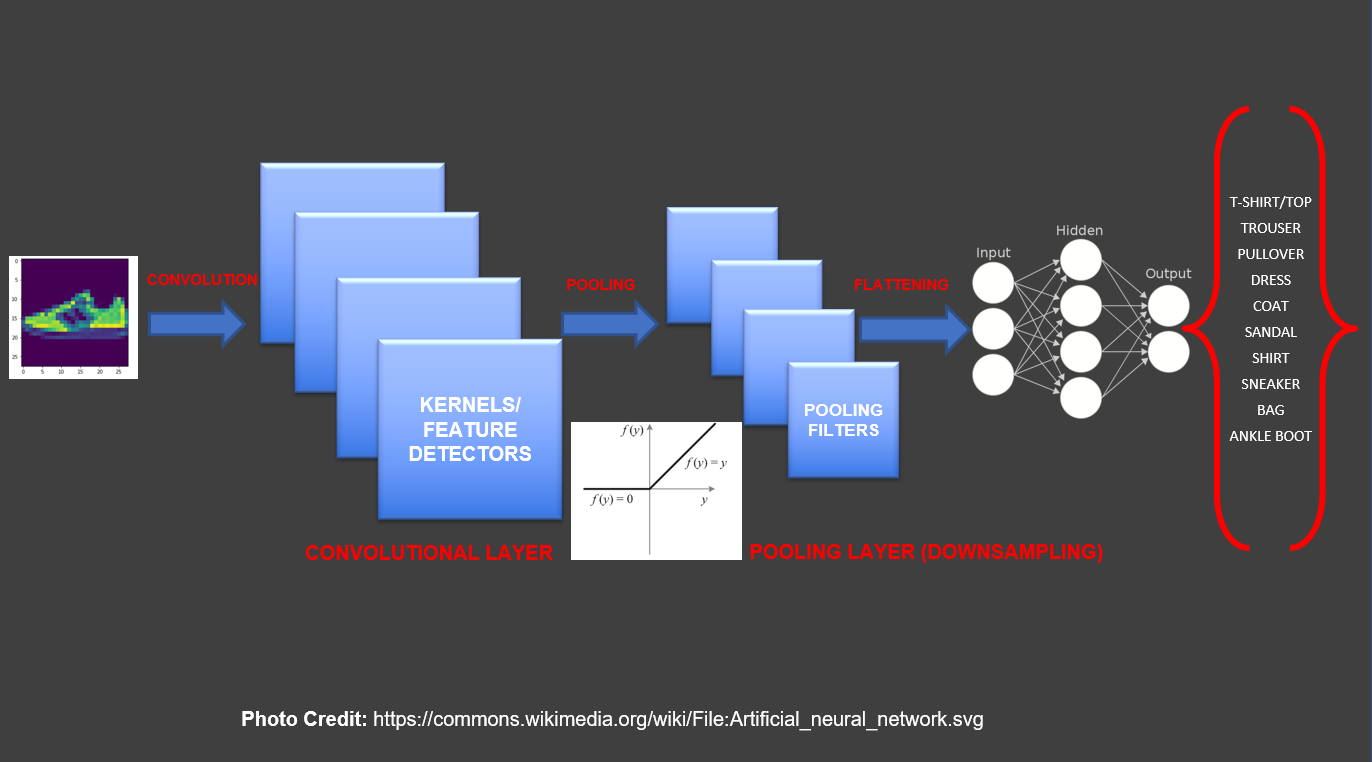

In [10]:
from tensorflow.keras import models, layers

model = models.Sequential()
model.add(layers.Input(shape=(28, 28, 1)))
# First Convolutional Block
model.add(layers.Conv2D(32, (3, 3), activation="relu"))
model.add(layers.MaxPooling2D(2, 2))

# Second Convolutional Block
model.add(layers.Conv2D(64, (3, 3), activation="relu"))
model.add(layers.MaxPooling2D(2, 2))

# Third Convolutional Block
model.add(layers.Conv2D(64, (3, 3), activation="relu"))

# Flatten and Dense Layers
model.add(layers.Flatten())
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dense(10, activation="softmax"))  # 10 classes for fashion items

# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

# TASK #6: COMPILE AND TRAIN A DEEP LEARNING MODEL

In [11]:
# Step 1: Compile the model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

print("Model compiled successfully!")

Model compiled successfully!


In [12]:
# Step 2: Train the model
print("Starting training...")

history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=10,
    validation_data=(X_test, y_test),
    verbose=1,  # Show progress
)

print("Training completed!")

Starting training...
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8204 - loss: 0.4894 - val_accuracy: 0.8626 - val_loss: 0.3753
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8849 - loss: 0.3162 - val_accuracy: 0.8908 - val_loss: 0.3099
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9009 - loss: 0.2713 - val_accuracy: 0.8977 - val_loss: 0.2855
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9091 - loss: 0.2416 - val_accuracy: 0.9025 - val_loss: 0.2651
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9199 - loss: 0.2174 - val_accuracy: 0.9028 - val_loss: 0.2677
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9265 - loss: 0.1974 - val_accuracy: 0.9064 - val_loss: 0.2592
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9335 - loss: 0.1781 - val_accuracy: 0.9051 - val_loss: 0.2640
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accur

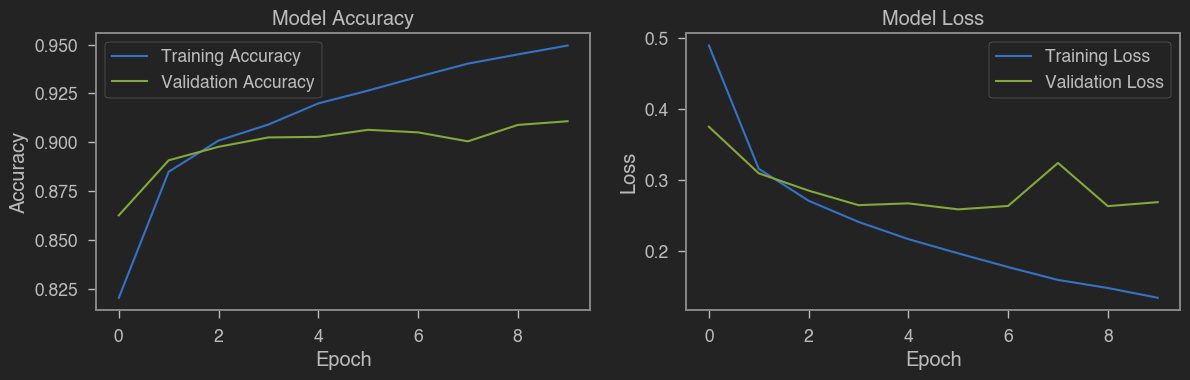

In [13]:
# Step 3: Plot training history
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# Task 7: Perform hyperparameter tuning using Keras Tuner.
Example: Define a custom tuner class implementing Bayesian Optimization for tuning model parameters.


In [14]:
import keras_tuner as kt
from tensorflow.keras import models, layers


def build_model(hp):
    model = models.Sequential()
    model.add(layers.Input(shape=(28, 28, 1)))

    # Architecture-related: Number of filters
    model.add(
        layers.Conv2D(
            hp.Choice("conv1_filters", [16, 32, 64]), (3, 3), activation="relu"
        )
    )
    model.add(layers.MaxPooling2D(2, 2))

    model.add(
        layers.Conv2D(
            hp.Choice("conv2_filters", [32, 64, 128]), (3, 3), activation="relu"
        )
    )
    model.add(layers.MaxPooling2D(2, 2))

    model.add(
        layers.Conv2D(
            hp.Choice("conv3_filters", [32, 64, 128]), (3, 3), activation="relu"
        )
    )
    model.add(layers.Flatten())

    # Architecture-related: Number of neurons in dense layer
    model.add(layers.Dense(hp.Choice("dense_units", [64, 128, 256]), activation="relu"))

    # Training-related: Dropout
    if hp.Boolean("use_dropout"):
        model.add(layers.Dropout(0.3))

    model.add(layers.Dense(10, activation="softmax"))

    # Training-related: optimizer and learning rate
    optimizer_name = hp.Choice("optimizer", ["adam", "rmsprop", "sgd"])
    learning_rate = hp.Choice("learning_rate", [0.0001, 0.001, 0.01])

    if optimizer_name == "adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == "rmsprop":
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:  # sgd
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"]
    )

    return model


# Create simple tuner
tuner = kt.BayesianOptimization(
    hypermodel=build_model,
    objective="val_accuracy",
    max_trials=15,
    directory="simple_tuning",
    project_name="fashion_simple",
)

# Search
tuner.search(X_train, y_train, epochs=5, validation_data=(X_test, y_test), verbose=1)

# Get best model
best_model = tuner.get_best_models()[0]
best_hps = tuner.get_best_hyperparameters()[0]

print("Best hyperparameters found:")
print(f"Optimizer: {best_hps.get('optimizer')}")
print(f"Learning Rate: {best_hps.get('learning_rate')}")
print(f"Conv1 Filters: {best_hps.get('conv1_filters')}")
print(f"Conv2 Filters: {best_hps.get('conv2_filters')}")
print(f"Conv3 Filters: {best_hps.get('conv3_filters')}")
print(f"Dense Units: {best_hps.get('dense_units')}")
print(f"Use Dropout: {best_hps.get('use_dropout')}")

Trial 15 Complete [00h 07m 46s]
val_accuracy: 0.8278999924659729

Best val_accuracy So Far: 0.9047999978065491
Total elapsed time: 00h 35m 07s
Best hyperparameters found:
Optimizer: adam
Learning Rate: 0.001
Conv1 Filters: 64
Conv2 Filters: 32
Conv3 Filters: 128
Dense Units: 256
Use Dropout: False


/Users/anhngo/Desktop/MSE/.venv/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


# TASK #8: ASSESS TRAINED THE BEST MODEL PERFORMANCE

In [21]:
print("\nEvaluating model performance...")

# Make predictions
y_pred = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Calculate accuracy
test_loss, test_accuracy = best_model.evaluate(X_test, y_test, verbose=0)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Evaluating model performance...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Test Accuracy: 0.9048
Test Loss: 0.2670


In [ ]:
# Classification Report
from sklearn.metrics import classification_report, confusion_matrix

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.89      0.87      1000
     Trouser       1.00      0.97      0.98      1000
    Pullover       0.79      0.92      0.85      1000
       Dress       0.91      0.92      0.92      1000
        Coat       0.85      0.82      0.84      1000
      Sandal       0.99      0.96      0.98      1000
       Shirt       0.78      0.65      0.71      1000
     Sneaker       0.93      0.99      0.96      1000
         Bag       0.97      0.99      0.98      1000
  Ankle boot       0.98      0.95      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.91      0.90      0.90     10000
weighted avg       0.91      0.90      0.90     10000



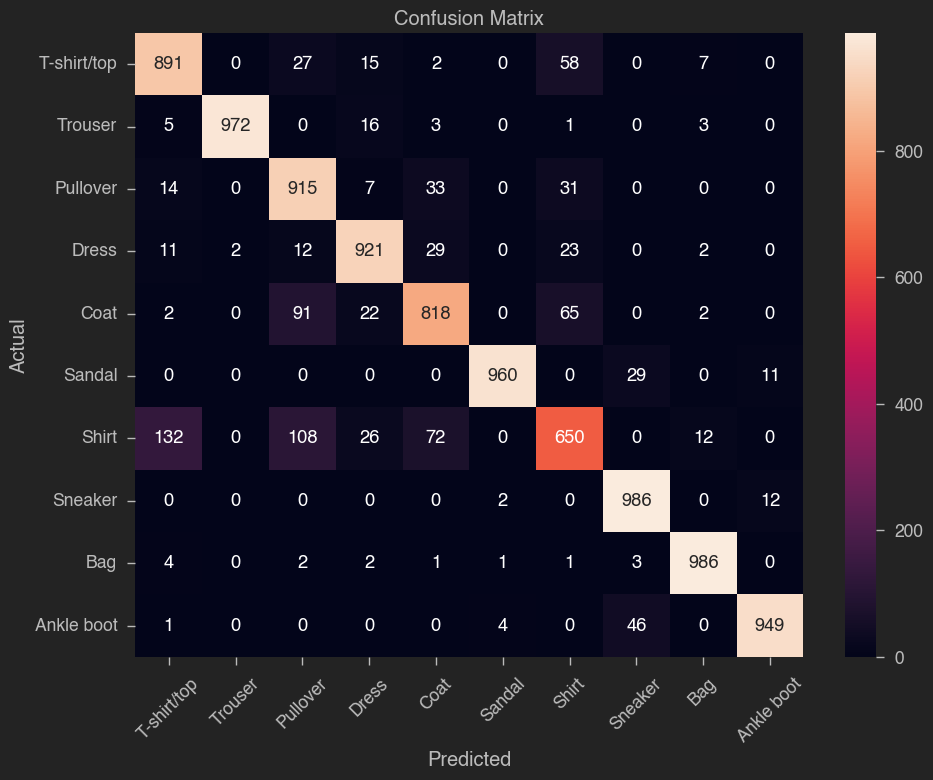

In [27]:
# Confusion Matrix
import seaborn as sns

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred_classes)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

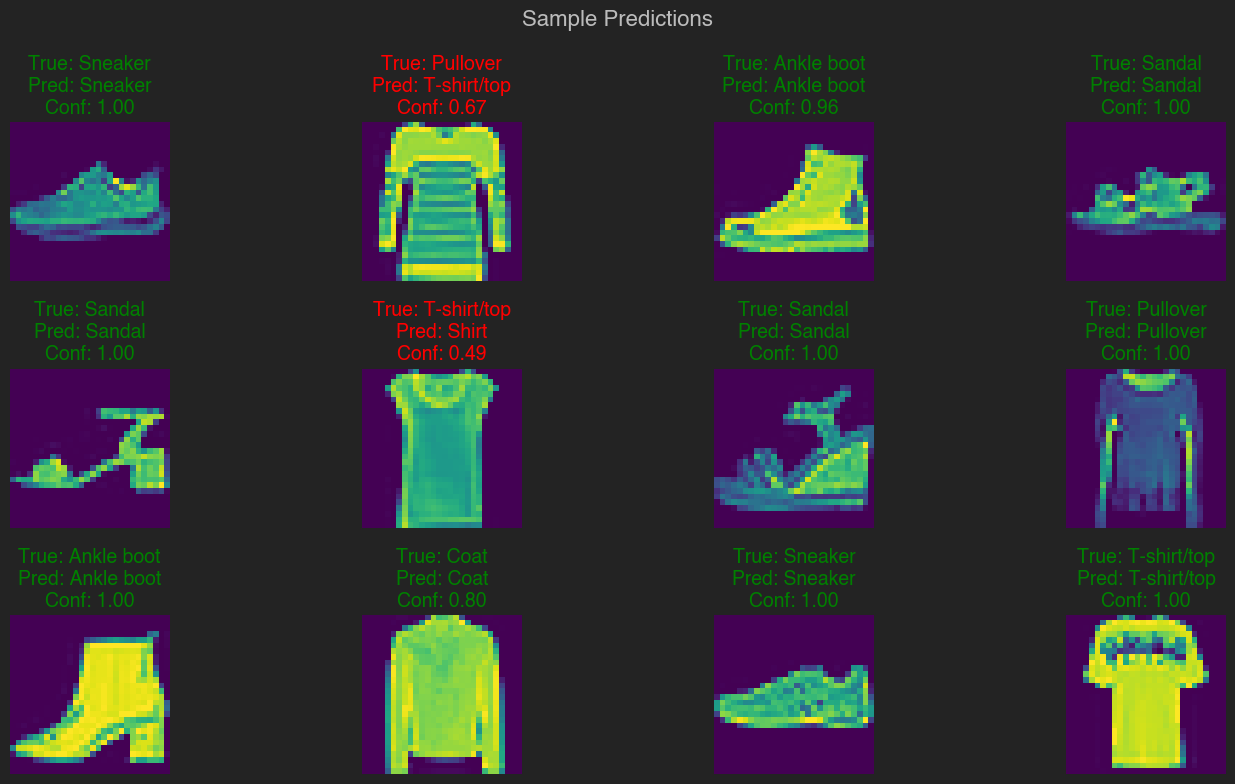

In [32]:
# Sample predictions

indices = np.random.choice(len(X_test), 12, replace=False)

plt.figure(figsize=(15, 8))
for i, idx in enumerate(indices):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28))

    predicted_class = y_pred_classes[idx]
    true_class = y_true[idx]
    confidence = np.max(y_pred[idx])

    # Color: green if correct, red if wrong
    color = "green" if predicted_class == true_class else "red"

    plt.title(
        f"True: {class_names[true_class]}\n"
        f"Pred: {class_names[predicted_class]}\n"
        f"Conf: {confidence:.2f}",
        color=color,
        fontsize=14,
    )
    plt.axis("off")

plt.suptitle("Sample Predictions", fontsize=16)
plt.tight_layout()
plt.show()

**PRACTICE OPPORTUNITY #3:**
- **Add a new dense layer containing 1024 neurons**
- **Increase the number of epochs**
- **Plot the model summary and determine the number of trainable parameters**
- **Retrain the model and evaluate its performance**

In [33]:
from tensorflow.keras import datasets, layers, models

cnn = models.Sequential()
cnn.add(layers.Input(shape=(28, 28, 1)))

cnn.add(layers.Conv2D(32, (3, 3), activation="relu"))
cnn.add(layers.MaxPooling2D(2, 2))

cnn.add(layers.Conv2D(64, (3, 3), activation="relu"))
cnn.add(layers.MaxPooling2D(2, 2))

cnn.add(layers.Conv2D(64, (3, 3), activation="relu"))

cnn.add(layers.Flatten())

cnn.add(layers.Dense(64, activation="relu"))
cnn.add(layers.Dense(1024, activation="relu"))
cnn.add(layers.Dense(10, activation="softmax"))
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169,482 (662.04 KB)

 Trainable params: 169,482 (662.04 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [35]:
history = cnn.fit(
    X_train, y_train,
    epochs=15,                    # Increased epochs
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.8095 - loss: 0.5002 - val_accuracy: 0.8707 - val_loss: 0.3559
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8838 - loss: 0.3162 - val_accuracy: 0.8836 - val_loss: 0.3097
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8988 - loss: 0.2718 - val_accuracy: 0.8910 - val_loss: 0.2966
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9106 - loss: 0.2414 - val_accuracy: 0.8995 - val_loss: 0.2835
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9180 - loss: 0.2193 - val_accuracy: 0.8941 - val_loss: 0.2775
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9250 - loss: 0.1985 - val_accuracy: 0.9033 - val_loss: 0.2774
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9301 - loss: 0.1832 - val_accuracy: 0.9049 - val_loss: 0.2800
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9361 - loss: 0

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9062 - loss: 0.3481

Test Accuracy: 0.9062


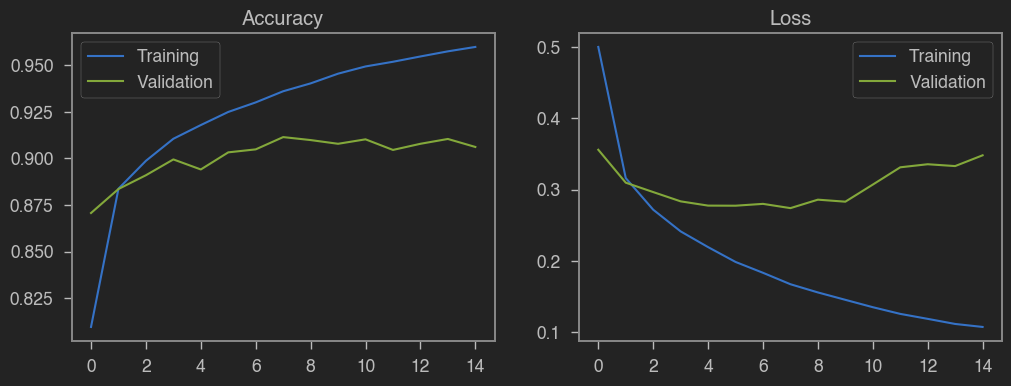

In [36]:
# Step 4: Evaluate performance
test_loss, test_accuracy = cnn.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

# Simple plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.show()

# GREAT JOB!

# PRACTICE OPPORTUNITIES SOLUTIONS 

**PRACTICE OPPORTUNITY #1 SOLUTION:**
- **Check out the sizes of both training and testing datasets**

In [ ]:
X_train.shape

In [ ]:
X_test.shape

In [ ]:
y_train.shape

In [ ]:
y_test.shape

**PRACTICE OPPORTUNITY #2 SOLUTION:**
- **Plot a grid containing 144 images and perform a sanity check on the data** 

In [ ]:
L = 7
W = 7
fig, axes = plt.subplots(L, W, figsize = (12,12))
axes = axes.ravel() 

for i in np.arange(0, L * W):  
    axes[i].imshow(X_test[i].reshape(28,28))
    axes[i].set_title("Prediction = {:0.1f}\n True = {:0.1f}".format(predicted_classes[i], y_test[i]))
    axes[i].axis('off')

plt.subplots_adjust(wspace=1)

**PRACTICE OPPORTUNITY #3 SOLUTION:**
- **Add a new dense layer containing 1024 neurons**
- **Increase the number of epochs**
- **Plot the model summary and determine the number of trainable parameters**
- **Retrain the model and evaluate its performance**

In [ ]:
from tensorflow.keras import datasets, layers, models
cnn = models.Sequential()

cnn.add(layers.Conv2D(32, (3,3), activation = 'relu', input_shape = (28, 28, 1)  ))
cnn.add(layers.MaxPooling2D(2,2))

cnn.add(layers.Conv2D(64, (3,3), activation = 'relu' ))
cnn.add(layers.MaxPooling2D(2,2))

cnn.add(layers.Conv2D(64, (3,3), activation = 'relu' ))

cnn.add(layers.Flatten())

cnn.add(layers.Dense(64, activation = 'relu'))
cnn.add(layers.Dense(1000, activation = 'relu'))
cnn.add(layers.Dense(10, activation = 'softmax'))
cnn.summary()